In [2]:
# directional distribution - south side

In [1]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import Point
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import re
from shapely.wkt import loads
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import altair as alt
from scipy import ndimage
from PIL import Image

In [2]:
commarea = gpd.read_file('south_chicago.geojson')
commarea.geometry = commarea.geometry.to_crs(epsg=26971)

In [3]:
hom_1940 = gpd.read_file('homcide-locations_1940-1964.csv')
hom_1940.POINT_X = hom_1940.POINT_X.astype(float)
hom_1940.POINT_Y = hom_1940.POINT_Y.astype(float)
hom_1940['geometry'] = hom_1940.apply(lambda x: Point(x.POINT_X, x.POINT_Y),
                                      axis=1)
hom_1940 = gpd.GeoDataFrame(hom_1940, geometry='geometry', crs='EPSG:4326')
hom_1940 = hom_1940.to_crs(epsg=26971)
hom_1940.year = hom_1940.year.astype(float).astype(int)
print(type(hom_1940))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [37]:
hom_1940.head()

,address_id,geo_strat,batch,file_name,page,case_no,dupe_id,date,home_addr,died_addr,...,clean_note,verd_note,news_links,id,year,month,verdict2,POINT_X,POINT_Y,geometry
0,1.000000000000000,gaps street lines,4.000000000000000,1940_02-06_VOL 1,306,86,,1940-05-23,1018 Polk St,1300 S Peoria St,...,"1300 S Peoria does not exist anymore, closest ...",,,1.000000000000000,1940,5.000000000000000,MURDER,-87.648924,41.865128,POINT (356821.92 577349.166)
1,2.000000000000000,census geocoder,1.000000000000000,1941_01_VOL 1,40,21,,1941-01-01,3520 Rhodes Ave,Bridewell Hospital,...,,,,2.000000000000000,1941,1.000000000000000,JUSTIFIABLE HOMICIDE,-87.614397,41.830600,POINT (359720.566 573537.607)
2,3.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,45,26,,1940-02-07,,Alley East of Clark-South of Grand Ave,...,"""IDENTIFY SLAIN BANDIT AS INSANE ASYLUM FUGITI...",,,3.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.630068,41.891584,POINT (358363.27 580300.268)
3,4.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,55,43,,1940-02-11,2000 Walnut St,2055 Lake St,...,,,,4.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.678073,41.884878,POINT (354385.025 579523.81)
4,5.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,57,46,,1940-02-12,1414 So Peoria St,,...,CCH,,,5.000000000000000,1940,2.000000000000000,MURDER,-87.648914,41.862169,POINT (356825.308 577020.469)


In [4]:
hom_1870 = gpd.read_file('homicide-locations_1870-1930.csv')
hom_1870.x = hom_1870.x.astype(float)
hom_1870.y = hom_1870.y.astype(float)
hom_1870['geometry'] = hom_1870.apply(lambda a: Point(a.x, a.y),
                                      axis=1)
hom_1870 = gpd.GeoDataFrame(hom_1870, geometry='geometry', crs='EPSG:4326')
hom_1870 = hom_1870.to_crs(epsg='26971')
hom_1870.year = hom_1870.year.astype(float).astype(int)
print(type(hom_1870))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [39]:
hom_1870.head()

,address,year,x,y,exact_date,geometry
0,144 Townsend St.,1904,-88.134440,41.724356,,POINT (316548.718 561506.589)
1,Liberty Hall,1902,-87.665551,41.900659,,POINT (355410.723 581284.65)
2,728 W. Monroe St.,1909,-87.675587,41.880076,,POINT (354595.49 578992.079)
3,6320 Madison (now Dorchester) Ave.,1909,-87.591816,41.779826,,POINT (361645.058 567914.179)
4,340 31st St.,1909,-87.627286,41.838252,,POINT (358642.929 574378.602)


In [5]:
hom_1940_south = gpd.sjoin(hom_1940, commarea, how='inner')
hom_1940_south.geometry.head()

1    POINT (359720.566 573537.607)
5    POINT (358383.261 570626.816)
7    POINT (359083.588 574668.592)
8    POINT (358286.082 574051.266)
9    POINT (358609.485 573348.023)
Name: geometry, dtype: geometry

In [6]:
hom_1870_south = gpd.sjoin(hom_1870, commarea, how='inner')
hom_1870_south.geometry.head()

3     POINT (361645.058 567914.179)
4     POINT (358642.929 574378.602)
9     POINT (358396.396 574236.291)
12    POINT (358701.541 574997.777)
13    POINT (358539.623 574496.827)
Name: geometry, dtype: geometry

In [31]:
def plot_directional_ellipse_gdf(gdf, ax=None, n_std=2.0, **kwargs):
    """
    Plot a directional (covariance-based) ellipse from a GeoDataFrame of Points.
    
    Parameters:
    - gdf: GeoDataFrame with Point geometries
    - ax: matplotlib axis (optional)
    - n_std: Number of standard deviations (e.g., 1, 2, 3)
    - kwargs: passed to matplotlib.patches.Ellipse (e.g., edgecolor, facecolor)
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Extract coordinates from geometry
    coords = np.array([[geom.x, geom.y] for geom in gdf.geometry if geom is not None])

    if len(coords) < 2:
        raise ValueError("Need at least two valid Point geometries to compute an ellipse.")

    # Compute mean and covariance
    mean = coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)

    # Eigen-decomposition of covariance matrix
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

    # Plot the points and ellipse
    gdf.plot(ax=ax, color='black', markersize=5)
    ax.set_aspect('equal')
    return ax

In [27]:
hom_1940_south.geometry.head()

1      POINT (-87.6144 41.8306)
5    POINT (-87.63078 41.80449)
7    POINT (-87.62195 41.84083)
8    POINT (-87.63161 41.83533)
9    POINT (-87.62779 41.82898)
Name: geometry, dtype: geometry

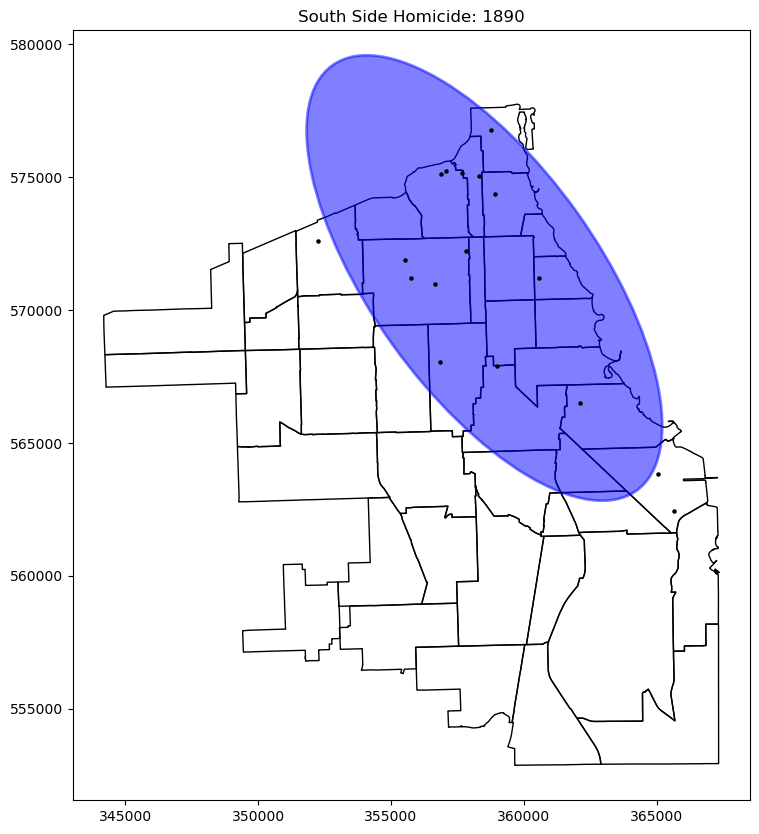

In [11]:
x=1890

fig, ax = plt.subplots(figsize=(10, 10))
commarea.to_crs('EPSG:26971').plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

plt.title(f'South Side Homicide: {x}')

plot_directional_ellipse_gdf(hom_1870_south[hom_1870_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
plt.show()

In [11]:
hom_1940_south.year.values

array([1941, 1940, 1940, ..., 1962, 1962, 1962], shape=(3762,))

In [11]:
plt.close()

In [12]:
print(sorted(hom_1940_south.year.unique()))

[np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1949), np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964)]


In [ ]:
file_names = []

for i in sorted(hom_1940_south.year.unique()):

    x=i

    fig, ax = plt.subplots(figsize=(10, 10))
    plt.ylim(41.63, 41.90)
    commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

    plt.title(f'South Side Homicide: {x}')

    plot_directional_ellipse_gdf(hom_1940_south[hom_1940_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
    plt.savefig(f'dir_dist/dist_{x}.png')
    file_names.append(f'dir_dist/dist_{x}.png')
    print(file_names)
    plt.close()

['dir_dist/dist_1940.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png', 'dir_dist/dist_1946.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png', 'dir_dist/dist_1946.png', 'dir_dist/dist_1947.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'di

In [12]:
def create_gif(file_names, gif_name, frame_duration=200):
    """
        Creates a GIF from images in a folder.
    
        Parameters:
        file_names: list of image paths
        gif_name (str): path of the output GIF file (e.g., "animation.gif").
        frame_duration (int): Duration of each frame in milliseconds.
    """
    images = []
    
        # Sort files to ensure correct order
    file_names.sort()
        
    for filename in file_names:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(filename)
                images.append(img)
            except Exception as e:
                print(f"Error opening image {filename}: {e}")
    
    if images:
        images[0].save(gif_name, save_all=True, append_images=images[1:], 
                          duration=frame_duration, loop=0)
        print(f"GIF saved as {gif_name} in {gif_name}")
    else:
        print("No valid images found in the specified folder.")

In [27]:
create_gif(file_names, 'dir_dist/1940_1964.gif')

GIF saved as dir_dist/1940_1964.gif in dir_dist/1940_1964.gif


In [15]:
hom_1940.head()

,address_id,geo_strat,batch,file_name,page,case_no,dupe_id,date,home_addr,died_addr,...,clean_note,verd_note,news_links,id,year,month,verdict2,POINT_X,POINT_Y,geometry
0,1.000000000000000,gaps street lines,4.000000000000000,1940_02-06_VOL 1,306,86,,1940-05-23,1018 Polk St,1300 S Peoria St,...,"1300 S Peoria does not exist anymore, closest ...",,,1.000000000000000,1940,5.000000000000000,MURDER,-87.648924,41.865128,POINT (-87.64892 41.86513)
1,2.000000000000000,census geocoder,1.000000000000000,1941_01_VOL 1,40,21,,1941-01-01,3520 Rhodes Ave,Bridewell Hospital,...,,,,2.000000000000000,1941,1.000000000000000,JUSTIFIABLE HOMICIDE,-87.614397,41.830600,POINT (-87.6144 41.8306)
2,3.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,45,26,,1940-02-07,,Alley East of Clark-South of Grand Ave,...,"""IDENTIFY SLAIN BANDIT AS INSANE ASYLUM FUGITI...",,,3.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.630068,41.891584,POINT (-87.63007 41.89158)
3,4.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,55,43,,1940-02-11,2000 Walnut St,2055 Lake St,...,,,,4.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.678073,41.884878,POINT (-87.67807 41.88488)
4,5.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,57,46,,1940-02-12,1414 So Peoria St,,...,CCH,,,5.000000000000000,1940,2.000000000000000,MURDER,-87.648914,41.862169,POINT (-87.64891 41.86217)


In [13]:
hom_1965 = gpd.read_file('locs_homicide_post_65.geojson', #crs='EPSG:26971'
                         )
hom_1965.year = hom_1965.year.astype(int)

In [14]:
hom_1965.geometry = hom_1965.geometry.centroid
hom_1965 = hom_1965.to_crs(epsg=26971)
hom_1965_south = gpd.sjoin(hom_1965, commarea, how='inner')


In [62]:
hom_1870_west = gpd.sjoin(hom_1870, commarea_west, how="inner")
hom_1940_west = gpd.sjoin(hom_1940, commarea_west, how="inner")
hom_1965_west = gpd.sjoin(hom_1965, commarea_west, how="inner")

west_hom = pd.concat([hom_1870_west, hom_1940_west, hom_1965_west])

In [15]:
south_hom = pd.concat([hom_1870_south, hom_1940_south, hom_1965_south])

In [67]:
for i in range(1870, 2023):

    x=i

    fig, ax = plt.subplots(figsize=(10, 10))
    plt.ylim(550000, 580000)
    commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

    plt.title(f'South Side Homicide: {x}', fontsize=14)

    if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
        print(south_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)

    plt.savefig(f'dir_dist/dist_{x}.png')
    print(f'dir_dist/dist_{x}.png')
    plt.close()

dir_dist/dist_1870.png
dir_dist/dist_1871.png
dir_dist/dist_1872.png
dir_dist/dist_1873.png
False
dir_dist/dist_1874.png
dir_dist/dist_1875.png
dir_dist/dist_1876.png
dir_dist/dist_1877.png
False
dir_dist/dist_1878.png
False
dir_dist/dist_1879.png
False
dir_dist/dist_1880.png
True
dir_dist/dist_1881.png
True
dir_dist/dist_1882.png
True
dir_dist/dist_1883.png
True
dir_dist/dist_1884.png
True
dir_dist/dist_1885.png
False
dir_dist/dist_1886.png
True
dir_dist/dist_1887.png
False
dir_dist/dist_1888.png
True
dir_dist/dist_1889.png
True
dir_dist/dist_1890.png
True
dir_dist/dist_1891.png
True
dir_dist/dist_1892.png
True
dir_dist/dist_1893.png
True
dir_dist/dist_1894.png
True
dir_dist/dist_1895.png
True
dir_dist/dist_1896.png
True
dir_dist/dist_1897.png
True
dir_dist/dist_1898.png
True
dir_dist/dist_1899.png
True
dir_dist/dist_1900.png
True
dir_dist/dist_1901.png
True
dir_dist/dist_1902.png
True
dir_dist/dist_1903.png
True
dir_dist/dist_1904.png
dir_dist/dist_1905.png
dir_dist/dist_1906.png
Tru

In [71]:
create_gif([f'dir_dist/dist_{x}.png' for x in range(1870, 2023)], 'dir_dist/1870_2022.gif')

GIF saved as dir_dist/1870_2022.gif in dir_dist/1870_2022.gif


In [72]:
create_gif([f'dir_dist/dist_{x}.png' for x in range(1940, 2023)], 'dir_dist/1940_2022.gif')

GIF saved as dir_dist/1940_2022.gif in dir_dist/1940_2022.gif


In [16]:
hexhom = gpd.read_file('Jada_Hexagons/hex_hom_bldg.shp')
hexhom = hexhom.to_crs(epsg=26971)
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.736 553447.796, 359285.268 55..."
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55..."
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55..."
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361787.828 552888.949, 361542.521 55..."
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.566 553473.32, 362288.34 5528..."


In [80]:
hexhom.year.unique()

array([1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884,
       1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895,
       1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906,
       1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917,
       1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928,
       1929, 1930, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948,
       1949, 1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959,
       1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970,
       1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981,
       1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992,
       1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014,
       2015, 2016], dtype=int32)

In [17]:
hexhom.sort_values(by=['GRID_ID', 'year'])
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.736 553447.796, 359285.268 55..."
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55..."
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55..."
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361787.828 552888.949, 361542.521 55..."
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.566 553473.32, 362288.34 5528..."


In [18]:
hexhom['cum_hom'] = hexhom.groupby('GRID_ID')['hom_ct'].cumsum()

In [120]:
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,cum_hom
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.736 553447.796, 359285.268 55...",0.0
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55...",0.0
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55...",0.0
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361787.828 552888.949, 361542.521 55...",0.0
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.566 553473.32, 362288.34 5528...",0.0


Text(0.5, 1.0, 'Hexhom year: 1960')

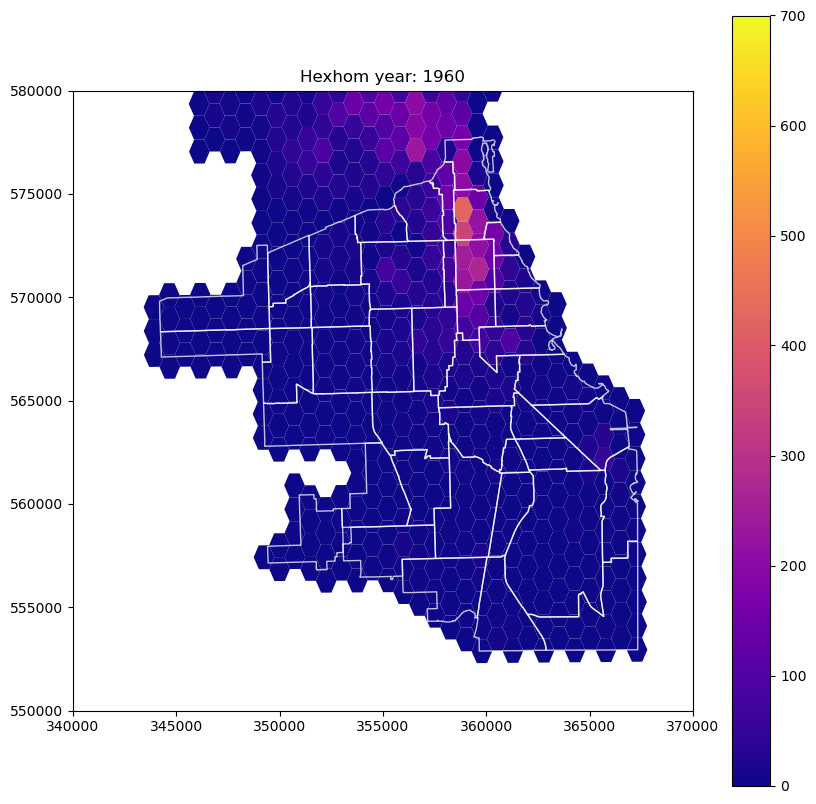

In [57]:
# test plot for cumulative heatmap for south side

x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

hexhom[hexhom.year==x].plot(column='cum_hom', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=700,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)
commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
plt.title(f'Hexhom year: {x}')
#plt.close()

In [23]:
hexhom.groupby('GRID_ID').cum_hom.max().describe()

count    821.000000
mean      60.523752
std       96.313290
min        0.000000
25%        3.000000
50%       17.000000
75%       77.000000
max      697.000000
Name: cum_hom, dtype: float64

In [24]:
hexhom['cum_hom_ceiling'] = hexhom.apply(lambda x:
                                      x.cum_hom if x.cum_hom <= 200 else 200,
                                      axis=1)

In [150]:
hexhom.head()

,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,cum_hom,cum_hom_ceiling
0,AJ-37,1874,0.0,0.000000,NaN,"POLYGON ((359530.736 553447.796, 359285.268 55...",0.0,0.0
1,AK-37,1874,0.0,4.198223,0.0,"POLYGON ((360286.292 552876.188, 360040.864 55...",0.0,0.0
2,AL-37,1874,0.0,0.001777,0.0,"POLYGON ((361032.151 553460.401, 360786.804 55...",0.0,0.0
3,AM-37,1874,0.0,0.000000,NaN,"POLYGON ((361787.828 552888.949, 361542.521 55...",0.0,0.0
4,AN-37,1874,0.0,0.000000,NaN,"POLYGON ((362533.566 553473.32, 362288.34 5528...",0.0,0.0


In [ ]:
# pngs for 'hex_cumu/cum_heatmap_1874_2016.gif'

most_recent = 1874

for x in range(1874, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(550000, 580000)
    plt.xlim(340000, 370000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom[hexhom.year==i].plot(column='cum_hom_ceiling', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=200,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)
    commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    plt.title(f'Hexhom year: {x}')
    most_recent = i
    plt.savefig(f'hex_cumu/cumsum_{x}.png')
    plt.close()

In [152]:
create_gif([f'hex_cumu/cumsum_{x}.png' for x in range(1874,2017)], 'hex_cumu/cum_heatmap_1874_2016.gif')

GIF saved as hex_cumu/cum_heatmap_1874_2016.gif in hex_cumu/cum_heatmap_1874_2016.gif


In [60]:
commarea_west = gpd.read_file('westside.geojson')
commarea_west = commarea_west.to_crs(epsg='26971')
commarea_west.head()

,name,geometry
0,westside,"POLYGON ((348903.44 572223.069, 348903.022 572..."


Text(0.5, 1.0, 'Hexhom year: 1960')

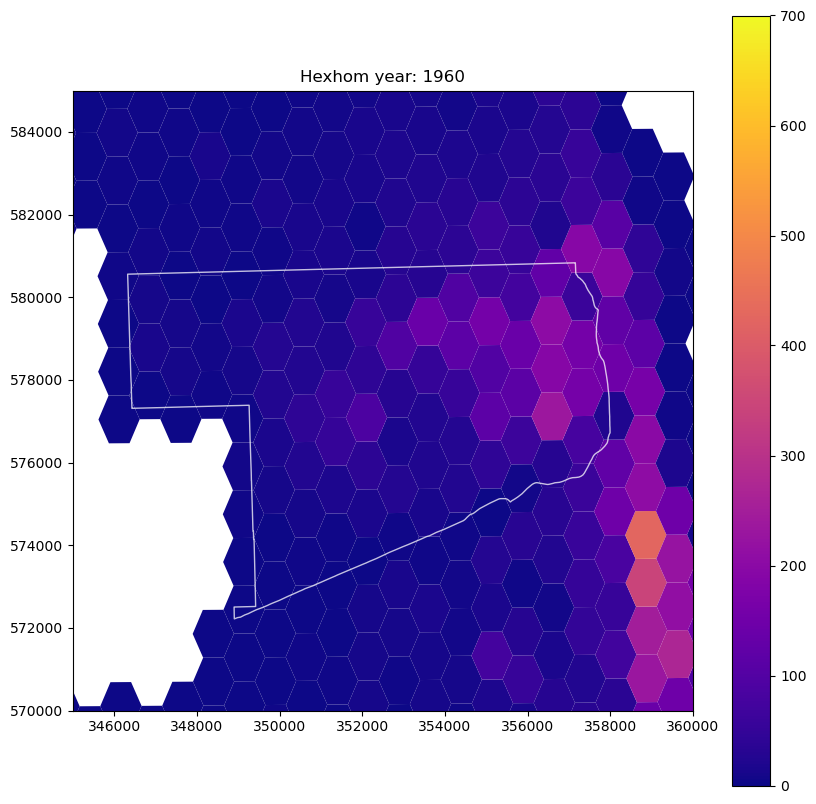

In [ ]:
# test plot for cum heatmap for westside

x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(570000, 585000)
plt.xlim(345000, 360000)

hexhom[hexhom.year==x].plot(column='cum_hom', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=700,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)
commarea_west.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
plt.title(f'Hexhom year: {x}')
plt.close()

In [164]:
most_recent = 1874

for x in range(1874, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(570000, 585000)
    plt.xlim(345000, 360000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom[hexhom.year==i].plot(column='cum_hom_ceiling', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=200,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)
    commarea_west.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    plt.title(f'Hexhom year: {x}')
    most_recent = i
    plt.savefig(f'hex_cumu_west/cumsum_west_{x}.png')
    plt.close()

In [165]:
create_gif([f'hex_cumu_west/cumsum_west_{x}.png' for x in range(1874, 2017)], 'hex_cumu_west/cum_heatmap_west_1874_2016.gif')

GIF saved as hex_cumu_west/cum_heatmap_west_1874_2016.gif in hex_cumu_west/cum_heatmap_west_1874_2016.gif


In [39]:
hexhom.year.describe()

count    110014.000000
mean       1945.671642
std          42.554071
min        1874.000000
25%        1907.000000
50%        1949.500000
75%        1983.000000
max        2016.000000
Name: year, dtype: float64

True


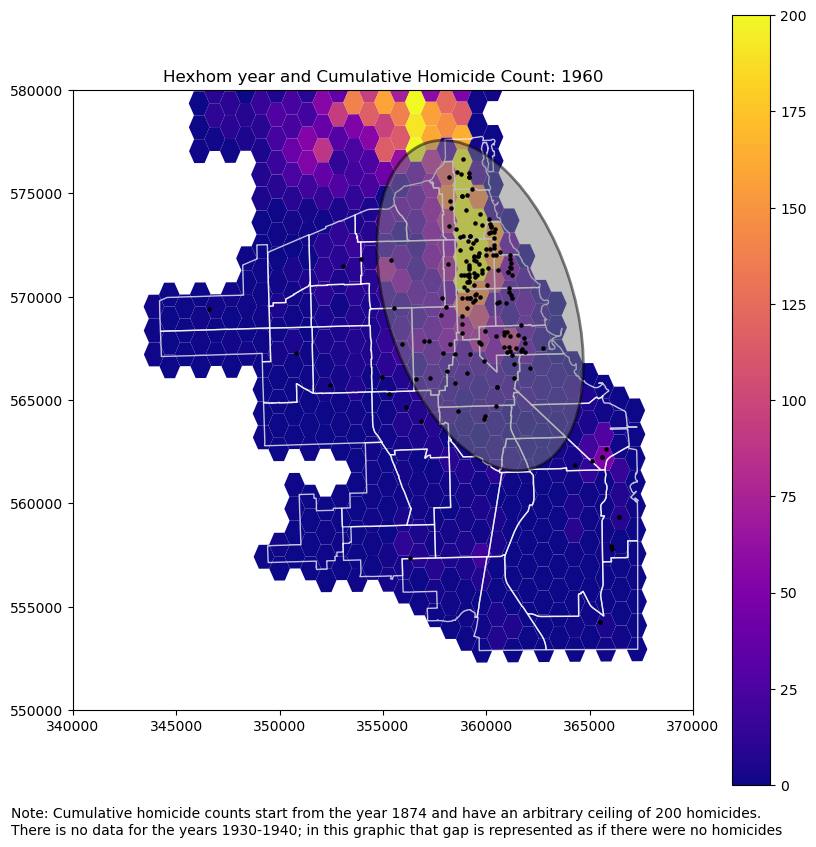

In [53]:
# adding directional ellipse and cumulative heatmap: south side test plot

x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(550000, 580000)
plt.xlim(340000, 370000)

hexhom[hexhom.year==x].plot(column='cum_hom', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=200,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)

commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)

if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
    print(south_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='gray',
                                 linewidth=2, alpha=0.5,
                                 )

plt.title(f'Hexhom year and Cumulative Homicide Count: {x}')
ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()

In [58]:
most_recent = 1874

for x in range(1874, 2017):
    fig, ax = plt.subplots(figsize=(10,10))

    i = x

    plt.ylim(550000, 580000)
    plt.xlim(340000, 370000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom[hexhom.year==i].plot(column='cum_hom_ceiling', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=200,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)
    commarea.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)
    plt.title(f'Hexhom year and Cumulative Homicide Count: {x}')

    if (x in south_hom.year.unique()) and (south_hom.year.value_counts()[x] >= 2):
        print(south_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(south_hom[south_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='gray',
                                    linewidth=2, alpha=0.5,
                                    )    
    ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
    plt.savefig(f'dist_cum_south/dist_cum_south_{x}.png')
    print(f'dist_cum_south/dist_cum_south_{x}.png')
    plt.close()
    most_recent = i

False
dist_cum_south/dist_cum_south_1874.png
dist_cum_south/dist_cum_south_1875.png
dist_cum_south/dist_cum_south_1876.png
dist_cum_south/dist_cum_south_1877.png
False
dist_cum_south/dist_cum_south_1878.png
False
dist_cum_south/dist_cum_south_1879.png
False
dist_cum_south/dist_cum_south_1880.png
True
dist_cum_south/dist_cum_south_1881.png
True
dist_cum_south/dist_cum_south_1882.png
True
dist_cum_south/dist_cum_south_1883.png
True
dist_cum_south/dist_cum_south_1884.png
True
dist_cum_south/dist_cum_south_1885.png
False
dist_cum_south/dist_cum_south_1886.png
True
dist_cum_south/dist_cum_south_1887.png
False
dist_cum_south/dist_cum_south_1888.png
True
dist_cum_south/dist_cum_south_1889.png
True
dist_cum_south/dist_cum_south_1890.png
True
dist_cum_south/dist_cum_south_1891.png
True
dist_cum_south/dist_cum_south_1892.png
True
dist_cum_south/dist_cum_south_1893.png
True
dist_cum_south/dist_cum_south_1894.png
True
dist_cum_south/dist_cum_south_1895.png
True
dist_cum_south/dist_cum_south_1896.p

In [59]:
create_gif([f'dist_cum_south/dist_cum_south_{x}.png' for x in range(1874, 2017)], 'dist_cum_south/dist_cum_south_1874_2016.gif')

GIF saved as dist_cum_south/dist_cum_south_1874_2016.gif in dist_cum_south/dist_cum_south_1874_2016.gif


True


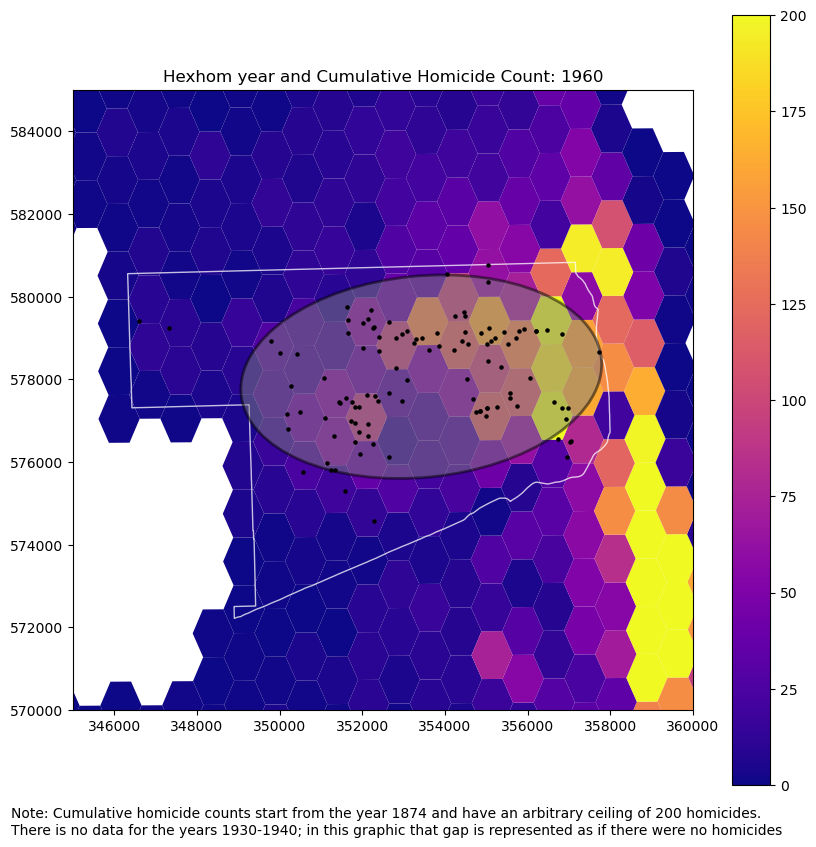

In [63]:
# test plot for cumulative heatmap + directional ellipse: west side:
x = 1960

fig, ax = plt.subplots(figsize=(10,10))

plt.ylim(570000, 585000)
plt.xlim(345000, 360000)

hexhom[hexhom.year==x].plot(column='cum_hom', 
                            cmap='plasma', 
                            legend=True, 
                            vmin=0,
                            vmax=200,
                            linewidth=0.1,
                            #alpha=0.75,
                            ax=ax)

commarea_west.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)

if (x in west_hom.year.unique()) and (west_hom.year.value_counts()[x] >= 2):
    print(west_hom.year.value_counts()[x] >= 5)
    plot_directional_ellipse_gdf(west_hom[west_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                  facecolor='gray',
                                 linewidth=2, alpha=0.5,
                                 )

plt.title(f'Hexhom year and Cumulative Homicide Count: {x}')
ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
            xy=(-0.1,-0.2),
            xycoords='axes fraction',
            fontsize=10)
plt.show()


In [65]:
most_recent = 1874

for x in range(1874, 2017):

    i = x

    fig, ax = plt.subplots(figsize=(10,10))

    plt.ylim(570000, 585000)
    plt.xlim(345000, 360000)

    if i not in hexhom.year.unique():
        i = most_recent

    hexhom[hexhom.year==i].plot(column='cum_hom_ceiling', 
                                cmap='plasma', 
                                legend=True, 
                                vmin=0,
                                vmax=200,
                                linewidth=0.1,
                                #alpha=0.75,
                                ax=ax)

    commarea_west.plot(facecolor="none", edgecolor="white", linewidth=1, ax=ax, alpha=0.75)

    if (x in west_hom.year.unique()) and (west_hom.year.value_counts()[x] >= 2):
        print(west_hom.year.value_counts()[x] >= 5)
        plot_directional_ellipse_gdf(west_hom[west_hom['year']==x], n_std=2, ax=ax, edgecolor='black',
                                    facecolor='gray',
                                    linewidth=2, alpha=0.5,
                                    )

    plt.title(f'Hexhom year and Cumulative Homicide Count: {x}')
    ax.annotate('Note: Cumulative homicide counts start from the year 1874 and have an arbitrary ceiling of 200 homicides.\nThere is no data for the years 1930-1940; in this graphic that gap is represented as if there were no homicides',
                xy=(-0.1,-0.2),
                xycoords='axes fraction',
                fontsize=10)
    
    most_recent = i
    
    plt.savefig(f'dist_cum_west/dist_cum_west_{x}.png')
    print(f'dist_cum_west/dist_cum_west_{x}.png')
    plt.close()

dist_cum_west/dist_cum_west_1874.png
True
dist_cum_west/dist_cum_west_1875.png
True
dist_cum_west/dist_cum_west_1876.png
True
dist_cum_west/dist_cum_west_1877.png
True
dist_cum_west/dist_cum_west_1878.png
True
dist_cum_west/dist_cum_west_1879.png
True
dist_cum_west/dist_cum_west_1880.png
True
dist_cum_west/dist_cum_west_1881.png
True
dist_cum_west/dist_cum_west_1882.png
True
dist_cum_west/dist_cum_west_1883.png
True
dist_cum_west/dist_cum_west_1884.png
True
dist_cum_west/dist_cum_west_1885.png
True
dist_cum_west/dist_cum_west_1886.png
True
dist_cum_west/dist_cum_west_1887.png
True
dist_cum_west/dist_cum_west_1888.png
True
dist_cum_west/dist_cum_west_1889.png
True
dist_cum_west/dist_cum_west_1890.png
True
dist_cum_west/dist_cum_west_1891.png
True
dist_cum_west/dist_cum_west_1892.png
True
dist_cum_west/dist_cum_west_1893.png
True
dist_cum_west/dist_cum_west_1894.png
True
dist_cum_west/dist_cum_west_1895.png
True
dist_cum_west/dist_cum_west_1896.png
True
dist_cum_west/dist_cum_west_1897.p

In [67]:
create_gif([f'dist_cum_west/dist_cum_west_{x}.png' for x in range(1874, 2017)], 'dist_cum_west/dist_cum_west_1874_2016.gif')

GIF saved as dist_cum_west/dist_cum_west_1874_2016.gif in dist_cum_west/dist_cum_west_1874_2016.gif
